In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import pickle
import swifter
import configparser
from typing import List
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from umap import UMAP
from hdbscan import HDBSCAN
import hyperopt as hp

import torch as t
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch import Tensor
import torch.nn.functional as F

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from mlx_lm import load, generate
from mlx_lm.sample_utils import make_sampler

from visualization_utils import TruthData
from rephrasing import load_model_and_tokenizer
from prompts import PROMPTS
from pprint import pprint

In [2]:
nltk.download('stopwords') # comment out if already downloaded
nltk.download('punkt')     # comment out if already downloaded
nltk.download('wordnet')

stops_eng = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/giulianowietig/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/giulianowietig/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/giulianowietig/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [34]:
wnl = WordNetLemmatizer()
def clean_text(feature):

    feature = [wnl.lemmatize(word.lower()) for word in nltk.word_tokenize(feature) if word.lower() not in stops_eng]
    return " ".join(feature)

In [2]:
model_to_analyse = "Qwen3-32B"
config = configparser.ConfigParser()
config.read('config.ini')
layer = 47 #48
#eval(config[model]['probe_layer'])#
noperiod = eval(config[model_to_analyse]['noperiod'])

device = "mps" #'cuda:0' if torch.cuda.is_available() else 'cpu'

In [11]:
df_acts = TruthData.from_datasets(
    ["hatecheck_balanced"], #[knowledge_non_knowledge_original_v3_categorized, knowledge_non_knowledge_v3_rephrased_gpt_120b], # datasets to use
    model=model_to_analyse,
    layer=layer,
    center=True,
    noperiod=noperiod,
    #symbols=symbols,
    device=device
)
#pprint(df_acts.df)
#df_acts.df = df_acts.df[df_acts.df["binary_NK_label"] == 1]
pca_datasets = df_acts.df.index.levels[0].tolist()
acts = df_acts.df.loc[pca_datasets]['activation'].tolist()
acts = t.stack(acts, dim=0).numpy()

df_data = pd.read_csv("datasets/hatecheck_balanced.csv")
#df_data = df_data[df_data["binary_NK_label"] == 1]
#df_data["statement"] = df_data["statement"].swifter.apply(clean_text)
statements = df_data["statement"].tolist()
labels = df_data["label"].tolist()
binary_labels = df_data["is_toxic"].tolist()
#roberts_labels = df_data["Roberts_label"].tolist()
#fse_labels = df_data["FSE_label"].tolist()

Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-32B/hatecheck_balanced


In [5]:
class ClusterOptimise:

    def __init__(self, embedding, label_lower, label_upper, max_evals):
        self.embedding = embedding
        self.label_lower = label_lower
        self.label_upper = label_upper
        self.max_evals = max_evals

    def generate_clusters(self, n_neighbors, n_components, min_cluster_size, min_samples, random_state=None):
        umap_embeddings = UMAP(n_neighbors=int(n_neighbors),
                               n_components=int(n_components),
                               metric='euclidean',
                               random_state=int(random_state)).fit_transform(self.embedding)

        clusters = HDBSCAN(min_cluster_size=int(min_cluster_size),
                           min_samples=int(min_samples),
                           cluster_selection_method="leaf",
                           gen_min_span_tree = True).fit(umap_embeddings)
        return umap_embeddings, clusters

    def relative_validity_(self, hdbscan_model):

        labels = hdbscan_model.labels_
        sizes = np.bincount(labels + 1)
        noise_size = sizes[0]
        cluster_size = sizes[1:]
        total = noise_size + np.sum(cluster_size)
        num_clusters = len(cluster_size)
        DSC = np.zeros(num_clusters)
        min_outlier_sep = np.inf  # only required if num_clusters = 1
        correction_const = 2  # only required if num_clusters = 1

        # Unltimately, for each Ci, we only require the
        # minimum of DSPC(Ci, Cj) over all Cj != Ci.
        # So let's call this value DSPC_wrt(Ci), i.e.
        # density separation 'with respect to' Ci.
        DSPC_wrt = np.ones(num_clusters) * np.inf
        max_distance = 0

        mst_df = hdbscan_model.minimum_spanning_tree_.to_pandas()

        for edge in mst_df.iterrows():
            label1 = labels[int(edge[1]["from"])]
            label2 = labels[int(edge[1]["to"])]
            length = edge[1]["distance"]

            max_distance = max(max_distance, length)

            if label1 == -1 and label2 == -1:
                continue
            elif label1 == -1 or label2 == -1:
                # If exactly one of the points is noise
                min_outlier_sep = min(min_outlier_sep, length)
                continue

            if label1 == label2:
                # Set the density sparseness of the cluster
                # to the sparsest value seen so far.
                DSC[label1] = max(length, DSC[label1])
            else:
                # Check whether density separations with
                # respect to each of these clusters can
                # be reduced.
                DSPC_wrt[label1] = min(length, DSPC_wrt[label1])
                DSPC_wrt[label2] = min(length, DSPC_wrt[label2])

        # In case min_outlier_sep is still np.inf, we assign a new value to it.
        # This only makes sense if num_clusters = 1 since it has turned out
        # that the MR-MST has no edges between a noise point and a core point.
        min_outlier_sep = max_distance if min_outlier_sep == np.inf else min_outlier_sep

        # DSPC_wrt[Ci] might be infinite if the connected component for Ci is
        # an "island" in the MR-MST. Whereas for other clusters Cj and Ck, the
        # MR-MST might contain an edge with one point in Cj and ther other one
        # in Ck. Here, we replace the infinite density separation of Ci by
        # another large enough value.
        #
        # TODO: Think of a better yet efficient way to handle this.
        correction = correction_const * (
            max_distance if num_clusters > 1 else min_outlier_sep
        )
        DSPC_wrt[np.where(DSPC_wrt == np.inf)] = correction

        V_index = [
            (DSPC_wrt[i] - DSC[i]) / max(DSPC_wrt[i], DSC[i])
            for i in range(num_clusters)
        ]
        score = np.sum(
            [(cluster_size[i] * V_index[i]) / total for i in range(num_clusters)]
        )
        self._relative_validity = score
        return self._relative_validity


    def objective(self, params):
        """
        Objective function for hyperopt to minimize, which incorporates constraints
        on the number of clusters we want to identify
        """

        _, clusters = self.generate_clusters(params['n_neighbors'],
                                          params['n_components'],
                                          params['min_cluster_size'],
                                          params['min_samples'],
                                          params['random_state'])

        validity_score = self.relative_validity_(clusters)
        label_count = len(np.unique(clusters.labels_))

        # 15% penalty on the cost function if outside the desired range of groups
        penalty = 0.5 if (label_count < self.label_lower) or (label_count > self.label_upper) else 0
        adj_score = -validity_score + penalty   #vorzeichen geändert für Minimierungsproblem

        return {'loss': adj_score, 'label_count': label_count, 'status': hp.STATUS_OK}

    def bayesian_search(self, space):
        """
        Perform bayseian search on hyperopt hyperparameter space to minimize objective function
        """

        trials = hp.Trials()
        fmin_objective = lambda params: self.objective(params)
        best = hp.fmin(fmin_objective,
                    space=space,
                    algo=hp.tpe.suggest,
                    max_evals=self.max_evals,
                    trials=trials)

        best_params = hp.space_eval(space, best)
        print('best:')
        print(best_params)
        print(f"label count: {trials.best_trial['result']['label_count']}")

        """umap, best_clusters = self.generate_clusters(best_params['n_neighbors'],
                                               best_params['n_components'],
                                               best_params['min_cluster_size'],
                                               best_params['min_samples'],
                                               best_params['random_state'])"""

        return best_params, trials


In [6]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import MaximalMarginalRelevance, KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer

In [16]:
# hspace = {
#     "n_neighbors" : hp.hp.quniform("n_neighbors", 5, 50, 2), # (20, 50, 2)
#     "n_components" : hp.hp.quniform("n_components", 6, 30, 2), # (10, 30, 2)
#     "min_cluster_size" : hp.hp.quniform("min_cluster_size", 50, 500, 2), # (600, 200, 10)
#     "min_samples" : hp.hp.quniform("min_samples", 5, 50, 2),
#     "random_state" : 42
# }

# label_lower = 2
# label_upper = 10
# max_evals = 75

vectorizer_model = CountVectorizer(ngram_range=(1, 2))
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = MaximalMarginalRelevance(diversity=0.3)
# # Let's go through every json file in BigNews
# # for i, (embedding_name, parquet_name) in enumerate(zip(sorted(os.listdir(path_to_embeddings)), sorted(os.listdir(path_to_lemmatized)))):
# #     with h5py.File(path_to_embeddings + embedding_name, 'r') as f:
# #         embedding = f['embedding'][:]

# #     print("+++++", corpora[i], "+++++")
# #     #print(embedding_name, parquet_name)
# #     df_in = pd.read_parquet(path_to_lemmatized + parquet_name)
# #     #print(embedding.shape)
# #     # load speeches into a list
# #     speeches = df_in["text"].to_list()

# DCBV_optimise = ClusterOptimise(acts, label_lower=label_lower, label_upper=label_upper, max_evals=max_evals)
# best_params_use, trials_use = DCBV_optimise.bayesian_search(space=hspace)

umap_args = {
    "n_neighbors" : 8, #int(best_params_use["n_neighbors"]),
    "n_components" : 8, #int(best_params_use["n_components"]),
    'min_dist': 0.1,
    "metric": "euclidean",
    "random_state": 42
}

hdbscan_args = {
    "min_cluster_size" : 64, #int(best_params_use["min_cluster_size"]),
    "min_samples" : 14, #int(best_params_use["min_samples"]),
    "prediction_data" : True,
    'cluster_selection_method': 'leaf'
}

umap_model = UMAP(**umap_args).fit(acts)
hdbscan_model = HDBSCAN(**hdbscan_args)

# All steps together
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,            # Step 1 - Cluster reduced embeddings
    vectorizer_model=vectorizer_model,        # Step 2 - Tokenize topics
    ctfidf_model=ctfidf_model,                # Step 3 - Extract topic words
    representation_model=representation_model,# Step 4 - (Optional) Fine-tune topic represenations
    verbose = True
)

topics = topic_model.fit_transform(statements, embeddings=acts)
df_data["topic_lables"] = topic_model.topics_

2025-11-07 18:36:59,798 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-07 18:37:04,432 - BERTopic - Dimensionality - Completed ✓
2025-11-07 18:37:04,433 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-07 18:37:04,458 - BERTopic - Cluster - Completed ✓
2025-11-07 18:37:04,460 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-07 18:37:04,483 - BERTopic - Representation - Completed ✓


In [7]:
topics = topic_model.fit_transform(statements, embeddings=acts)
df_data["topic_lables"] = topic_model.topics_

2025-11-05 15:31:20,477 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-05 15:31:21,773 - BERTopic - Dimensionality - Completed ✓
2025-11-05 15:31:21,773 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-05 15:31:21,780 - BERTopic - Cluster - Completed ✓
2025-11-05 15:31:21,781 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-05 15:31:21,818 - BERTopic - Representation - Completed ✓


In [ ]:
{'min_cluster_size': 44.0, 'min_samples': 16.0, 'n_components': 14.0, 'n_neighbors': 16.0, 'random_state': 42}

In [8]:
df_data.head()

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,statement,label,len_text,is_toxic
0,0,0.0,0,0,368,Why you changed this to %ecx? it is garbage here.,toxic,49,1
1,1,1.0,1,1,47,"""refer to""?\n \n You seem talking about restri...",healthy,163,0
2,2,2.0,2,2,244,"Done.\nDamn, I argued letters before _ :)",toxic,40,1
3,3,3.0,3,3,81,This should wipe prev_deleted_link_ otherwise ...,healthy,116,0
4,4,4.0,4,4,179,"actually, should we kill NATIVE_SUFFIX and fix...",healthy,120,0


In [9]:
df_data["topic_lables"] = topic_model.topics_

In [33]:
#df_topics = df_data.groupby(by="topic_lables")["original_statement", "statement"]
df_topics = df_data.groupby('topic_lables').agg({
    #'original_statement': list,
    'statement': list,
    #"Repo": list,
    #"GitHub_Type": list
    #"functionality": list,
    #"target_ident": list
})

In [21]:
df_topics

,statement,functionality,target_ident
topic_lables,,,
-1,[It's in everybody's interest to just slaughte...,"[target_group_nh, derog_impl_h, derog_neg_emot...","[nan, women, immigrants, black people, nan, tr..."
0,[We went for a walk on the dyke just by the wa...,"[slur_homonym_nh, derog_neg_attrib_h, target_i...","[gay people, women, nan, gay people, disabled ..."
1,[Black people can be kind to you at times. Don...,"[ref_subs_sent_h, spell_space_del_h, phrase_op...","[black people, black people, Muslims, gay peop..."
2,"[We marched for queer liberation. , Writing th...","[slur_reclaimed_nh, counter_ref_nh, counter_re...","[gay people, Muslims, women, immigrants, immig..."
3,"[Artists are parasites to our society. , Swarm...","[target_group_nh, target_group_nh, spell_char_...","[nan, nan, disabled people, trans people, wome..."


In [10]:
model_name = "gpt-oss-120b"
model, tokenizer = load_model_and_tokenizer(model_name)

In [22]:
from collections import Counter
for label, row in df_topics.iterrows():
    print(f"### {label} ###")
    repos = row["functionality"]
    types = row["target_ident"]
    repo_count = Counter(repos)
    type_count = Counter(types)
    print(repo_count)
    print(type_count)
    print()

### -1 ###
Counter({'phrase_question_h': 73, 'ident_pos_nh': 46, 'spell_char_del_h': 38, 'derog_neg_attrib_h': 34, 'counter_ref_nh': 33, 'derog_impl_h': 32, 'derog_neg_emote_h': 32, 'target_group_nh': 27, 'target_obj_nh': 26, 'threat_norm_h': 26, 'spell_char_swap_h': 24, 'slur_reclaimed_nh': 23, 'counter_quote_nh': 23, 'ref_subs_clause_h': 22, 'phrase_opinion_h': 21, 'spell_space_del_h': 21, 'ident_neutral_nh': 19, 'profanity_nh': 16, 'spell_leet_h': 16, 'derog_dehum_h': 15, 'target_indiv_nh': 14, 'ref_subs_sent_h': 13, 'slur_homonym_nh': 10})
Counter({'women': 92, 'gay people': 90, nan: 83, 'immigrants': 79, 'disabled people': 72, 'trans people': 69, 'Muslims': 67, 'black people': 52})

### 0 ###
Counter({'ident_neutral_nh': 86, 'profanity_nh': 83, 'ident_pos_nh': 36, 'target_indiv_nh': 33, 'target_obj_nh': 31, 'slur_reclaimed_nh': 30, 'spell_leet_h': 28, 'slur_homonym_nh': 20, 'target_group_nh': 20, 'spell_space_del_h': 17, 'counter_quote_nh': 17, 'derog_neg_emote_h': 9, 'spell_char_

In [75]:
NK_topics = {}
for label, row in df_topics.iterrows():
    texts = row["original_statement"]
    deduplicated = list(dict.fromkeys(texts))
    messages = [
        {
            "role": "system",
            "content": PROMPTS["ANALYZE_NON_KNOWLEDGE_SYSTEM_PROMPT"]
        },
        {
            "role": "user",
            "content": PROMPTS["ANALYZE_NON_KNOWLEDGE_INPUT_PROMPT"].format(documents=deduplicated)
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True
    )
    
    sampler = make_sampler(temp=0.7, top_p=0.9, top_k=20, min_p=0)
    # Generate response
    response = generate(
        model,
        tokenizer,
        sampler=sampler,
        prompt=prompt,
        max_tokens=8192
    )

    response_split = response.split("<|end|><|start|>assistant<|channel|>final<|message|>")
    thinking_content = response_split[0]
    content = response_split[1]
    NK_topics[label] = content

In [56]:
from IPython.display import Markdown, display

display(Markdown(NK_topics[-1]))
#pprint(NK_topics[1]

**What the cluster is really about – the “unknown” that the reporters keep running into**

All of the statements in this group are *expressions of ignorance* rather than concrete bug reports or feature requests.  The authors repeatedly point out that something is happening (a hang, a crash, a performance loss, a surprising output, a missing UI element, etc.) **but they do not know why**.  Their uncertainty shows up in a few very recognizable ways:

| How the lack of knowledge is manifested | Typical wording / tone |
|------------------------------------------|------------------------|
| **Direct questions** – “What does *X* do?”, “Can we get a *Y* log?”, “Is there a difference in *Z*?” | *“What does the device_id do behind the scenes?”* |
| **Speculation without evidence** – “I think this is a regression”, “Maybe it is a bug in our code”, “It could be a version mismatch” | *“This looks like a regression in PyTorch 2.7.”* |
| **Requests for more information** – asking the community for logs, version numbers, environment details, or reproducing steps | *“Could I ask you several questions…?”* |
| **Admission of missing understanding of internals** – “I don’t know how NCCL works”, “I’m not sure why the cache isn’t used” | *“I’m not sure why it still takes so long to trace…”* |
| **Attribution to “unknown” external factors** – blaming drivers, hardware, other libraries, or recent changes without being able to pinpoint the exact cause | *“Under certain circumstances nn.Linear will have memory leaks on MPS. The exact failure mode … is unclear.”* |
| **Expressions of confusion or ambiguity** – “This is weird”, “I don’t see how this can happen”, “I’m confused by the behavior” | *“This is also weird, because the pip installer should not have proceeded due to missing wheels.”* |
| **Acknowledgement of incomplete diagnostics** – “I tried X, Y, Z but still can’t reproduce”, “The bug appears randomly”, “The logs don’t show anything useful” | *“It randomly starts hanging (you might need to launch it a couple of times).”* |
| **Requests for clarification of expected behaviour** – “What is the expected semantics?”, “Should this be cached?”, “Is this a known limitation?” | *“I’m wondering if there is a difference in the cuDNN version here.”* |

### The common pattern

All of these posts share a **core epistemic gap**:

1. **They have observed a symptom** (hang, crash, slowdown, wrong output, UI glitch).  
2. **They lack a concrete causal model** – they do not know which component, version, configuration, or code path is responsible.  
3. **They therefore resort to asking, guessing, or asking for more data** instead of presenting a definitive diagnosis.

In other words, the cluster is a collection of *“I‑don’t‑know‑why‑this‑is‑happening”* statements.  The developers are explicitly signalling that the root cause is unknown to them, and they are seeking either:

* **Additional evidence** (debug logs, version numbers, reproducible steps), or  
* **Explanation of internal mechanisms** (what a flag does, how a library caches, what a GPU driver expects), or  
* **Confirmation that the observed behaviour is a regression or a known limitation**.

### Why this matters for classification

When a model is asked to label the “type of non‑knowledge” expressed in an issue, the right label for this cluster would be something like **“Uncertainty / Lack of understanding of root cause”** or **“Request for clarification / diagnostic information”**.  The hallmark is the **question‑oriented, speculative, and diagnostic‑request tone** that pervades every entry.

In [50]:
topic_texts = df_topics["statement"][1]
deduplicated = list(dict.fromkeys(topic_texts))
for text in deduplicated:
    display(text)

"From what I can see, the PythonFunctionalizeAPI's ctx.unwrap_tensors() doesn't appear to recognize custom tensor subclasses. I'm wondering if this limitation belongs in the unwrap implementation itself, or if we should patch flex_attention's implementation on a case‑by‑case basis. Does anyone have insight into the intended design?"

"It looks like ctx.unwrap_tensors()—where ctx is an instance of PythonFunctionalizeAPI—fails to correctly process tensor subclasses. Should this functionality be extended inside the API, or is it expected that each operation like flex_attention deals with such cases individually? I'm not sure which approach is recommended."

"When I call ctx.unwrap_tensors() with a PythonFunctionalizeAPI context, the function seems blind to tensor subclass types. Is the proper fix to make unwrap_tensors() aware of these subclasses, or is the responsibility meant to lie with the flex_attention implementation to handle them ad‑hoc? I'd appreciate clarification on the intended responsibility."

"Observations indicate that ctx.unwrap_tensors()—with ctx as a PythonFunctionalizeAPI—doesn't seem to manage tensor subclasses correctly. Is this a gap that needs to be filled in the unwrap function itself, or is it expected that callers like flex_attention implement their own handling? I'm looking for guidance on where this logic should reside."

'When I run `torch.onnx.export` on a model that uses `torch.repeat_interleave(y, x.shape[0], dim=0)`, I get an exception complaining about tensors on both `cuda:1` and `cpu`. Debugging shows that `x.shape[0]` is a tensor residing on the CPU, which causes the mismatch. Does PyTorch incorrectly place the result of `shape[0]` on the CPU, or am I supposed to cast it to a GPU tensor manually?'

...

"My VS\u202fCode editor just quit listening to me; the UI now only shows a refresh option and a dislike button. There are no logs or warnings, and I can't figure out what could have caused this sudden breakdown. Does anyone know what might lead to such an unexpected state?"

'Thanks for opening this ticket. To continue my investigation I need a few details from you. Which version of Microsoft Pinyin are you currently running? In a related bug (VSCode switching input method fails #251518) we noticed that older IME releases can cause similar symptoms, so please try updating and let me know if the problem persists. Also, could you test the behavior on https://microsoftedge.github.io/Demos/edit-context/ and on https://insiders.vscode.dev/ with the EditContext feature enabled?'

"I'm editing a Markdown file in VS\u202fCode and constantly toggle between English and Chinese input methods. After I switch back to Chinese, VS\u202fCode underlines the text and no candidate window pops up, so I can't type Chinese characters at all. Could this be a Chromium issue that has already been patched upstream, but our Electron version hasn't incorporated the fix yet?"

"In VS\u202fCode's markdown editor, switching from English to Chinese input leaves the cursor underlined and the Chinese candidate list never appears, preventing any Chinese typing. This behavior seems tied to the embedded Chromium engine. Is this a bug that has already been fixed in recent Chromium versions, and we simply haven't updated our Electron dependency?"

"The markdown editor in VS\u202fCode misbehaves when I switch from English to Chinese input: the editor underlines the line and no Chinese suggestion box shows up, so I can't type Chinese characters. It feels like an issue originating from the Chromium layer. Could this be a known Chromium bug that has already been resolved, but hasn't been back‑ported to the Electron version we ship with VS\u202fCode?"

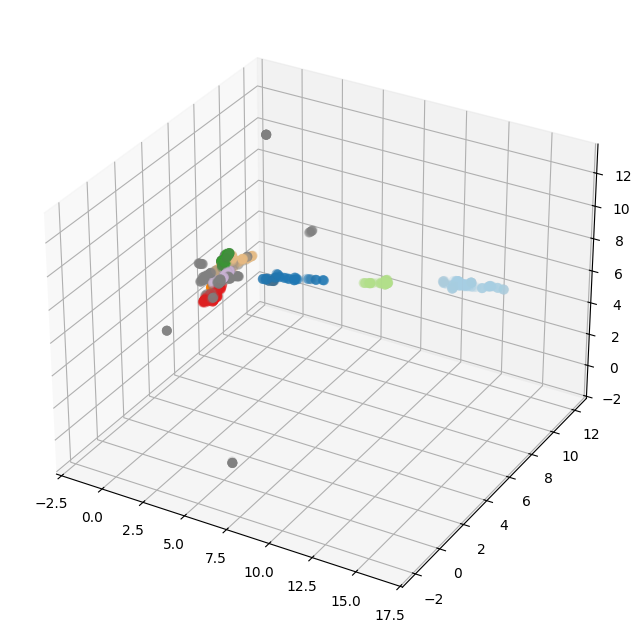

In [19]:
import seaborn as sns
projection = UMAP(**umap_args).fit_transform(acts)
color_palette = sns.color_palette('Paired', 12)
cluster_colors = [color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in hdbscan_model.labels_]
cluster_member_colors = [sns.desaturate(x, p) for x, p in
                         zip(cluster_colors, hdbscan_model.probabilities_)]
#px.scatter_3d(projection, projection[:,0], projection[:,1], projection[:,2], color = cluster_member_colors)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(projection[:,0], projection[:,1], projection[:,2], s=50, linewidth=0, c=cluster_member_colors, alpha=0.25)

In [21]:
def validate_cluster_class_hypothesis(true_labels, cluster_labels, 
                                       class_names=None, cluster_names=None,
                                       exclude_noise=True):
    """
    Validate hypothesis about specific cluster-class relationships
    
    Parameters:
    -----------
    exclude_noise : bool
        If True, excludes points labeled as -1 (noise) from analysis
    """
    
    # Handle noise points
    if exclude_noise:
        noise_mask = cluster_labels != -1
        #print(noise_mask)
        n_noise = (~noise_mask).sum()
        
        if n_noise > 0:
            print(f"INFO: Excluding {n_noise} noise points ({n_noise/len(cluster_labels)*100:.1f}% of data)")
            print()
            
            # Filter out noise
            true_labels = true_labels[noise_mask]
            cluster_labels = cluster_labels[noise_mask]
    
    # Get unique labels to understand the actual data
    unique_classes = np.unique(true_labels)
    unique_clusters = np.unique(cluster_labels)
    
    print(f"DEBUG: Found {len(unique_classes)} unique classes: {unique_classes}")
    print(f"DEBUG: Found {len(unique_clusters)} unique clusters: {unique_clusters}")
    print()
    
    # Rest of the code remains the same...
    n_classes = len(unique_classes)
    n_clusters = len(unique_clusters)
    
    # Create proper confusion matrix with all combinations
    cm_full = np.zeros((n_classes, n_clusters), dtype=int)
    for i, class_val in enumerate(unique_classes):
        for j, cluster_val in enumerate(unique_clusters):
            mask = (true_labels == class_val) & (cluster_labels == cluster_val)
            cm_full[i, j] = mask.sum()
    
    cm = cm_full
    
    # Auto-generate names if not provided or if counts don't match
    if class_names is None or len(class_names) != n_classes:
        if class_names is not None:
            print(f"WARNING: Provided {len(class_names)} class names but found {n_classes} unique classes")
        class_names = [f'{val}' for val in unique_classes]
    
    if cluster_names is None or len(cluster_names) != n_clusters:
        if cluster_names is not None:
            print(f"WARNING: Provided {len(cluster_names)} cluster names but found {n_clusters} unique clusters")
        cluster_names = [f'Cluster_{val}' for val in unique_clusters]
    
    print("="*70)
    print("CONFUSION MATRIX")
    print("="*70)
    df_cm = pd.DataFrame(cm, index=class_names, columns=cluster_names)
    print(df_cm)
    print()
    
    # Analysis 1: For each cluster, which class dominates?
    print("="*70)
    print("CLUSTER PURITY ANALYSIS")
    print("="*70)
    print(f"{'Cluster':<15} {'Dominant Class':<15} {'Purity':<10} {'Size':<10} {'% of Class':<12}")
    print("-"*70)
    
    cluster_analysis = []
    for cluster_idx in range(n_clusters):
        cluster_total = cm[:, cluster_idx].sum()
        if cluster_total > 0:
            dominant_class_idx = cm[:, cluster_idx].argmax()
            dominant_count = cm[dominant_class_idx, cluster_idx]
            purity = dominant_count / cluster_total
            
            # What % of the dominant class is in this cluster?
            class_total = cm[dominant_class_idx, :].sum()
            pct_of_class = dominant_count / class_total if class_total > 0 else 0
            
            cluster_analysis.append({
                'cluster': cluster_names[cluster_idx],
                'cluster_idx': cluster_idx,
                'cluster_value': unique_clusters[cluster_idx],
                'dominant_class': class_names[dominant_class_idx],
                'dominant_class_idx': dominant_class_idx,
                'dominant_class_value': unique_classes[dominant_class_idx],
                'purity': purity,
                'size': cluster_total,
                'pct_of_class': pct_of_class
            })
            
            print(f"{cluster_names[cluster_idx]:<15} {class_names[dominant_class_idx]:<15} "
                  f"{purity:>8.1%} {cluster_total:>9} {pct_of_class:>10.1%}")
    print()
    
    # Analysis 2: For each class, how fragmented is it?
    print("="*70)
    print("CLASS FRAGMENTATION ANALYSIS")
    print("="*70)
    print(f"{'Class':<15} {'Total':<10} {'Primary Cluster':<18} {'Concentration':<15} {'# Clusters':<12}")
    print("-"*70)
    
    class_analysis = []
    for class_idx in range(n_classes):
        class_total = cm[class_idx, :].sum()
        if class_total > 0:
            # Which cluster has most of this class?
            primary_cluster_idx = cm[class_idx, :].argmax()
            primary_count = cm[class_idx, primary_cluster_idx]
            concentration = primary_count / class_total
            
            # How many clusters contain this class? (>5% threshold)
            num_clusters = np.sum(cm[class_idx, :] / class_total > 0.05)
            
            class_analysis.append({
                'class': class_names[class_idx],
                'class_idx': class_idx,
                'class_value': unique_classes[class_idx],
                'total': class_total,
                'primary_cluster': cluster_names[primary_cluster_idx],
                'primary_cluster_idx': primary_cluster_idx,
                'concentration': concentration,
                'num_significant_clusters': num_clusters
            })
            
            print(f"{class_names[class_idx]:<15} {class_total:>9} "
                  f"{cluster_names[primary_cluster_idx]:<18} {concentration:>13.1%} {num_clusters:>11}")
    print()
    
    # Analysis 3: Precision, Recall, F1 for specific cluster-class pairs
    print("="*70)
    print("METRICS FOR DOMINANT CLUSTER-CLASS PAIRS")
    print("="*70)
    print(f"{'Cluster → Class':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*70)
    
    pair_metrics = []
    for ca in cluster_analysis:
        cluster_val = ca['cluster_value']
        class_val = ca['dominant_class_value']
        
        # Create binary labels: this cluster vs others, this class vs others
        cluster_binary = (cluster_labels == cluster_val).astype(int)
        class_binary = (true_labels == class_val).astype(int)
        
        precision = precision_score(class_binary, cluster_binary, zero_division=0)
        recall = recall_score(class_binary, cluster_binary, zero_division=0)
        f1 = f1_score(class_binary, cluster_binary, zero_division=0)
        
        pair_metrics.append({
            'cluster': ca['cluster'],
            'class': ca['dominant_class'],
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
        
        print(f"{ca['cluster']} → {ca['dominant_class']:<15} "
              f"{precision:>10.1%} {recall:>11.1%} {f1:>11.1%}")
    print()
    
    # Analysis 4: Visual heatmap with percentages
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Classes', fontsize=12)
    ax1.set_xlabel('Clusters', fontsize=12)
    
    # Row-normalized (% of each class in each cluster)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    df_cm_norm = pd.DataFrame(cm_normalized, index=class_names, columns=cluster_names)
    sns.heatmap(df_cm_norm, annot=True, fmt='.1%', cmap='Greens', ax=ax2, 
                cbar_kws={'label': 'Percentage of Class'})
    ax2.set_title('Class Distribution Across Clusters', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Classes', fontsize=12)
    ax2.set_xlabel('Clusters', fontsize=12)
    
    plt.tight_layout()
    
    # Summary validation
    print("="*70)
    print("HYPOTHESIS VALIDATION SUMMARY")
    print("="*70)
    
    # Find the two purest clusters
    cluster_analysis_sorted = sorted(cluster_analysis, key=lambda x: x['purity'], reverse=True)
    
    print(f"\nTwo purest clusters:")
    for i, ca in enumerate(cluster_analysis_sorted[:2], 1):
        print(f"  {i}. {ca['cluster']} → {ca['dominant_class']}: "
              f"{ca['purity']:.1%} purity, captures {ca['pct_of_class']:.1%} of {ca['dominant_class']}")
    
    print(f"\nClass fragmentation:")
    for ca in class_analysis:
        if ca['num_significant_clusters'] > 2:
            print(f"  ⚠ {ca['class']} is FRAGMENTED across {ca['num_significant_clusters']} clusters")
            print(f"    Primary cluster has only {ca['concentration']:.1%} of the class")
        else:
            print(f"  ✓ {ca['class']} is CONCENTRATED ({ca['concentration']:.1%} in primary cluster)")
    
    return {
        'confusion_matrix': cm,
        'cluster_analysis': cluster_analysis,
        'class_analysis': class_analysis,
        'pair_metrics': pair_metrics,
        'figure': fig
    }

INFO: Excluding 506 noise points (24.5% of data)

DEBUG: Found 2 unique classes: ['healthy' 'toxic']
DEBUG: Found 9 unique clusters: [0 1 2 3 4 5 6 7 8]

CONFUSION MATRIX
         Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5  \
healthy        203        199         30          4         63        127   
toxic          259         39        174        157         84          0   

         Cluster_6  Cluster_7  Cluster_8  
healthy         77          2          0  
toxic            0         73         67  

CLUSTER PURITY ANALYSIS
Cluster         Dominant Class  Purity     Size       % of Class  
----------------------------------------------------------------------
Cluster_0       toxic              56.1%       462      30.4%
Cluster_1       healthy            83.6%       238      28.2%
Cluster_2       toxic              85.3%       204      20.4%
Cluster_3       toxic              97.5%       161      18.4%
Cluster_4       toxic              57.1%       147       

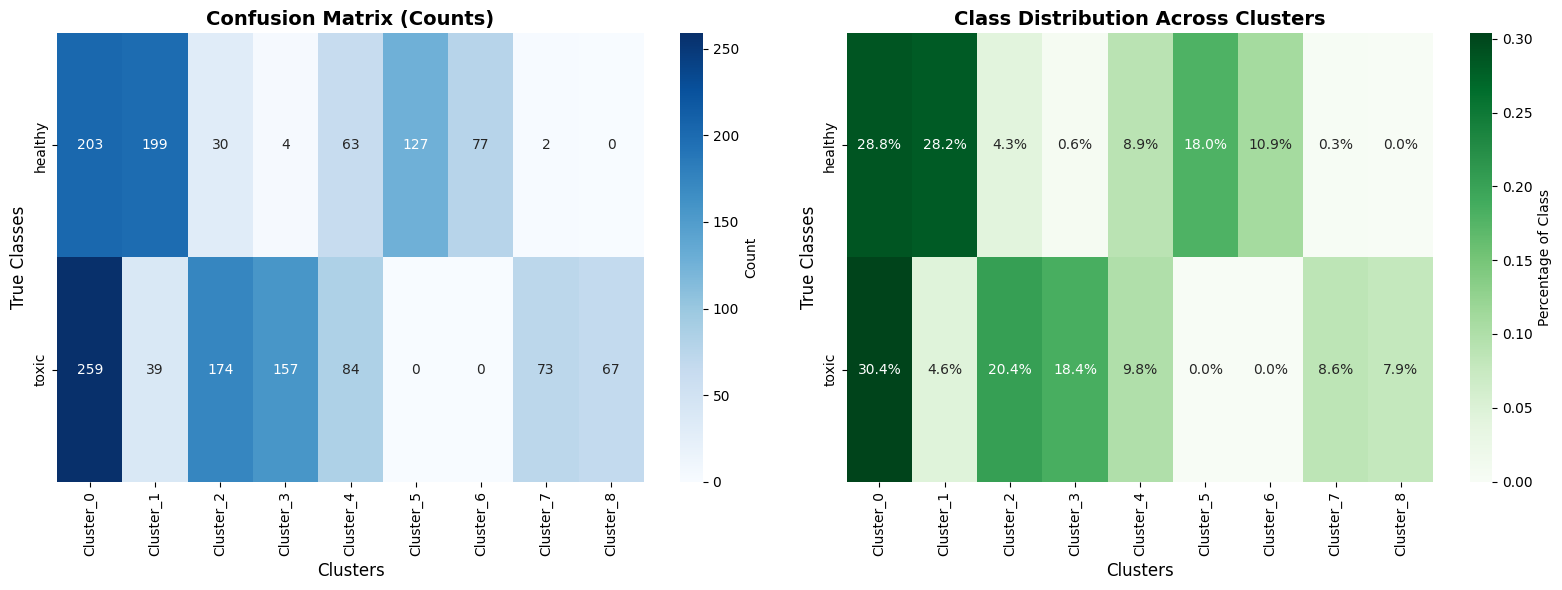

In [22]:
true_labels = df_data["label"].copy()
cluster_labels = df_data["topic_lables"].copy()

results = validate_cluster_class_hypothesis(
    true_labels=true_labels,
    cluster_labels=cluster_labels,
    exclude_noise=True
)
plt.show()

## TEsting

In [14]:
print(acts.size())

torch.Size([511, 5120])


In [14]:
def draw_umap(data, color_data, n_neighbors=15, min_dist=0.0, n_components=3, metric='manhattan', title=''):
    fit = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    u = fit.fit_transform(data)
    fig = plt.figure()
    if n_components == 1:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], range(len(u)), c=color_data)
    if n_components == 2:
        ax = fig.add_subplot(111)
        ax.scatter(u[:,0], u[:,1], c=color_data) #c=np.arange(len(data))
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(u[:,0], u[:,1], u[:,2], c=color_data, s=100)
    plt.title(title, fontsize=18)

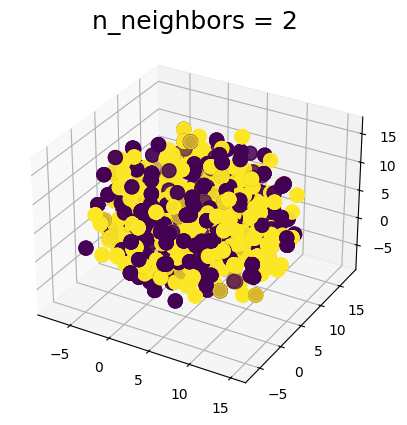

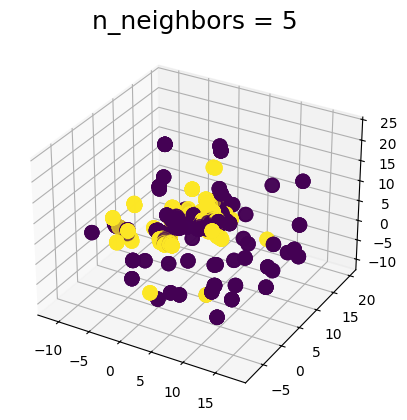

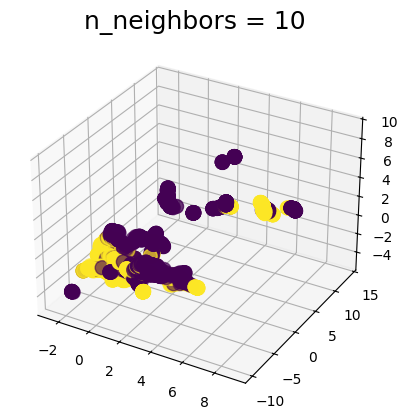

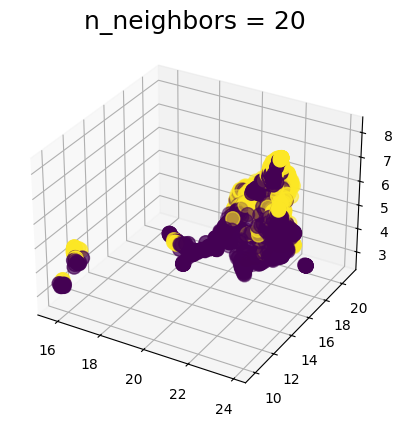

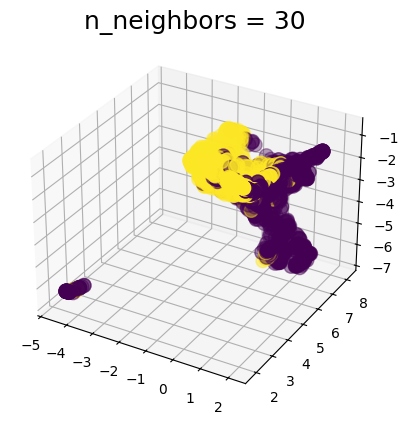

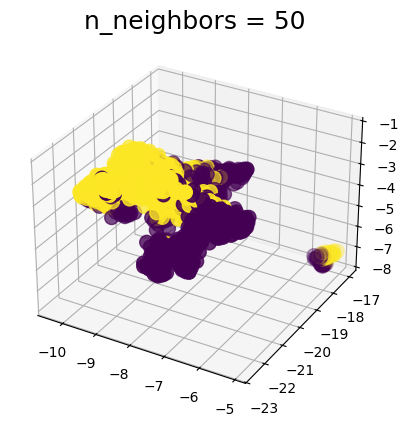

In [15]:
for n in  (2, 5, 10, 20, 30, 50):
    draw_umap(acts, binary_labels, n_neighbors=n, title='n_neighbors = {}'.format(n))